# AI Career Platform Lifecycle Growth Analysis

This notebook demonstrates the end-to-end MVP pipeline:
1. Load and validate synthetic data.
2. Compute growth funnel and cohort retention.
3. Analyze the onboarding A/B experiment.
4. Inspect churn labels and Next Best Action recommendations.

In [1]:
import json
import os
import sys

src_path = os.path.abspath('src')
if not os.path.exists(os.path.join(src_path, 'career_growth')):
    src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
sys.path.insert(0, src_path)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from career_growth.analytics.experiments import analyze_experiment
from career_growth.analytics.funnel import compute_funnel
from career_growth.analytics.retention import (
    compute_cohort_retention,
    compute_day_retention,
    compute_rolling_retention,
)
from career_growth.config import ONBOARDING_EXPERIMENT_ID, PREDICTION_CUTOFF_DAY
from career_growth.decisions.next_best_action import recommend_next_action
from career_growth.validation.validator import DataValidator

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load data

In [2]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

users = pd.read_csv('data/sample/users.csv', parse_dates=['signup_timestamp'])
events = pd.read_csv('data/sample/events.csv', parse_dates=['event_timestamp'])
experiment_assignments = pd.read_csv(
    'data/sample/experiment_assignments.csv', parse_dates=['assignment_time']
)
interventions = pd.read_csv('data/sample/interventions.csv', parse_dates=['send_time'])
labels = pd.read_csv('data/processed/labels.csv', parse_dates=['label_start', 'label_end'])

print(f'Users: {len(users):,}')
print(f'Events: {len(events):,}')
print(f'Interventions: {len(interventions):,}')

Users: 1,000
Events: 17,856
Interventions: 694


## 2. Data validation

In [3]:
validator = DataValidator('data')
validator.users = users
validator.events = events
validator.experiment_assignments = experiment_assignments
validator.interventions = interventions
validator.labels = labels
report = validator.validate()
print('Validation passed:', report.passed)
print('Errors:', report.errors)
print('Warnings:', report.warnings)

Validation passed: True
Errors: []
Warnings: []


## 3. User overview

In [4]:
overview = users.groupby('acquisition_channel').size().reset_index(name='users')
overview['share'] = overview['users'] / overview['users'].sum()
display(overview)

,acquisition_channel,users,share
0,campus_event,181,0.181
1,content_marketing,109,0.109
2,organic_search,352,0.352
3,referral,105,0.105
4,social_ads,253,0.253


## 4. Growth funnel

,step,users,conversion_rate,drop_off_rate
0,signup,1000,1.000,0.000000
1,onboarding_complete,416,0.416,0.584000
2,profile_complete,246,0.246,0.408654
3,resume_upload,121,0.121,0.508130
4,job_recommendation_view,67,0.067,0.446281
5,job_save,33,0.033,0.507463
6,career_report_generate,20,0.020,0.393939


C:\Users\Administrator\AppData\Local\Temp\ipykernel_5468\2345566079.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=funnel, x='step', y='users', palette='Blues_d', ax=ax)


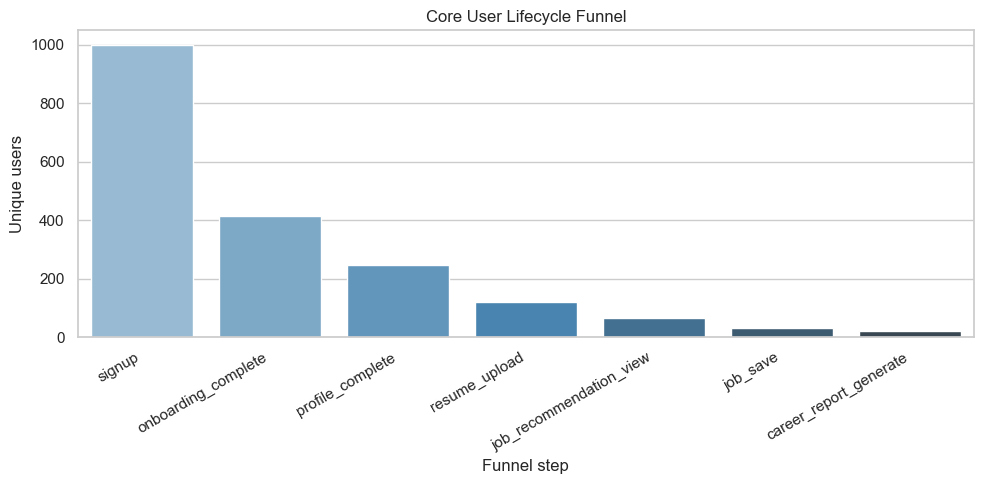

In [5]:
funnel = compute_funnel(users, events)
display(funnel)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=funnel, x='step', y='users', palette='Blues_d', ax=ax)
ax.set_title('Core User Lifecycle Funnel')
ax.set_xlabel('Funnel step')
ax.set_ylabel('Unique users')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 5. Retention

In [6]:
retention_summary = pd.DataFrame(
    [
        {'metric': 'D1 retention', 'rate': compute_day_retention(users, events, 1)['retention_rate'].iloc[0]},
        {'metric': 'D7 retention', 'rate': compute_day_retention(users, events, 7)['retention_rate'].iloc[0]},
        {'metric': 'D14 retention', 'rate': compute_day_retention(users, events, 14)['retention_rate'].iloc[0]},
        {
            'metric': f'D{PREDICTION_CUTOFF_DAY} rolling retention',
            'rate': compute_rolling_retention(users, events, PREDICTION_CUTOFF_DAY),
        },
    ]
)
display(retention_summary)

,metric,rate
0,D1 retention,0.674
1,D7 retention,0.467
2,D14 retention,0.079
3,D7 rolling retention,0.763


### Cohort retention heatmap

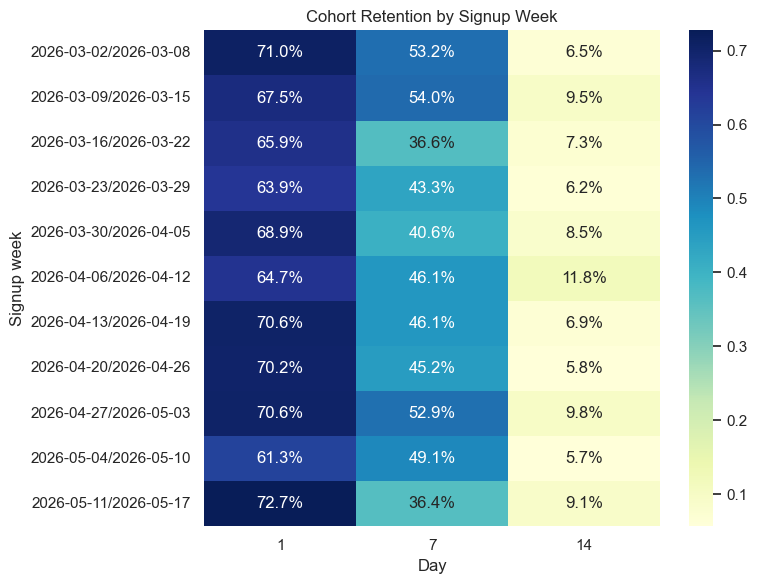

In [7]:
cohort = compute_cohort_retention(users, events, days=[1, 7, 14])
cohort_pivot = cohort.pivot(index='signup_week', columns='day', values='retention_rate')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cohort_pivot, annot=True, fmt='.1%', cmap='YlGnBu', ax=ax)
ax.set_title('Cohort Retention by Signup Week')
ax.set_xlabel('Day')
ax.set_ylabel('Signup week')
plt.tight_layout()
plt.show()

## 6. Churn label distribution

,acquisition_channel,churn_rate
4,social_ads,0.399209
2,organic_search,0.397727
0,campus_event,0.381215
1,content_marketing,0.376147
3,referral,0.371429


C:\Users\Administrator\AppData\Local\Temp\ipykernel_5468\4020678871.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_channel, x='acquisition_channel', y='churn_rate', palette='Reds_d', ax=ax)


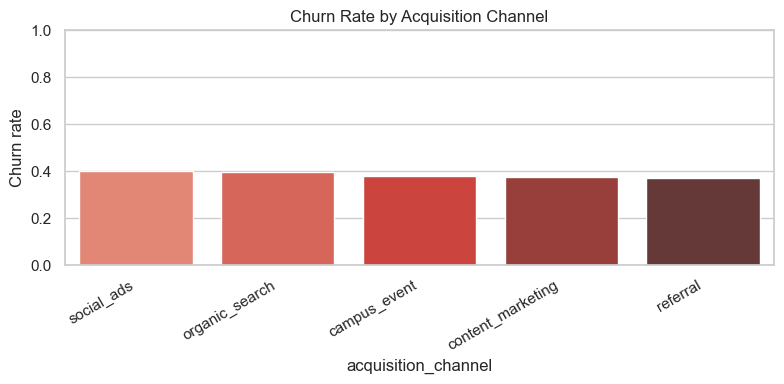

In [8]:
labeled = users.merge(labels[['user_id', 'is_churned']], on='user_id')
churn_by_channel = (
    labeled.groupby('acquisition_channel')['is_churned']
    .mean()
    .reset_index(name='churn_rate')
    .sort_values('churn_rate', ascending=False)
)
display(churn_by_channel)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=churn_by_channel, x='acquisition_channel', y='churn_rate', palette='Reds_d', ax=ax)
ax.set_title('Churn Rate by Acquisition Channel')
ax.set_ylabel('Churn rate')
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 7. Onboarding A/B experiment

In [9]:
experiment_results = analyze_experiment(
    users, events, experiment_assignments, ONBOARDING_EXPERIMENT_ID
)
print('Sample sizes:', experiment_results['sample_sizes'])
print('SRM p-value:', experiment_results['srm_p_value'])
print('')
for metric_name, results in experiment_results['metrics'].items():
    print(f'--- {metric_name} ---')
    for r in results:
        lift = r.get('relative_lift')
        lift_str = f'{lift:+.1%}' if lift is not None else 'control'
        print(
            f"{r['variant_id']:12s} n={r['sample_size']:<5d} rate={r['conversion_rate']:.2%} "
            f"lift={lift_str:<8s} p={r.get('p_value')}"
        )

Sample sizes: {'control': 377, 'personalized': 314, 'simplified': 309}
SRM p-value: 0.3253295316958106

--- onboarding_completion_rate ---
control      n=377   rate=38.20% lift=control  p=None
personalized n=314   rate=44.90% lift=+17.6%   p=0.07449148374066561
simplified   n=309   rate=42.39% lift=+11.0%   p=0.26424796171640574
--- profile_completion_rate ---
control      n=377   rate=39.79% lift=control  p=None
personalized n=314   rate=42.99% lift=+8.1%    p=0.3940069118817262
simplified   n=309   rate=43.37% lift=+9.0%    p=0.34384135883138667
--- d7_retention_rate ---
control      n=377   rate=48.54% lift=control  p=None
personalized n=314   rate=45.54% lift=-6.2%    p=0.43157436705896246
simplified   n=309   rate=45.63% lift=-6.0%    p=0.4474936199916453


## 8. Next Best Action sample

In [10]:
sample_users = users.sample(10, random_state=42)
recommendations = []
for _, user in sample_users.iterrows():
    rec = recommend_next_action(user, events)
    recommendations.append(
        {
            'user_id': user['user_id'][:8] + '...',
            'action': rec['action_name'],
            'channel': rec['channel'],
            'reason': rec['reason'],
        }
    )
display(pd.DataFrame(recommendations))

,user_id,action,channel,reason
0,9f108841...,complete_onboarding,in_app,onboarding not completed
1,36271320...,upload_resume,in_app,resume not uploaded
2,fa2b2c87...,complete_onboarding,in_app,onboarding not completed
3,63cfcf5e...,view_job_recommendations,in_app,job recommendations not viewed
4,7c205ac4...,complete_onboarding,in_app,onboarding not completed
5,022eff3c...,complete_onboarding,in_app,onboarding not completed
6,2cc678f4...,complete_onboarding,in_app,onboarding not completed
7,830e1072...,send_reengagement_message,email,high churn risk with marketing consent
8,a3fa9e81...,complete_onboarding,in_app,onboarding not completed
9,6f544f84...,complete_onboarding,in_app,onboarding not completed


## 9. Summary

- The synthetic dataset passes schema, temporal, and relational validation.
- Churn rate is within the target range and varies by acquisition channel.
- The onboarding experiment shows a measurable treatment effect with stable randomization.
- The rule-based Next Best Action engine assigns contextually appropriate recommendations.